In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/ML_LAB/Lab4/medical-charges.csv')

In [11]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
# Separate features (X) and target (y)
x = df.drop('charges', axis=1)
y = df['charges']

# Define which columns are categorical and which are numeric
categorical_cols = ['sex', 'smoker', 'region']
numeric_cols = ['age', 'bmi', 'children']

# Creating a transformer to handle encoding and scaling
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

# Apply the transformations
X_processed = preprocessor.fit_transform(x)

print(f"Original shape: {x.shape}")
print(f"Processed shape: {X_processed.shape}")

Original shape: (1338, 6)
Processed shape: (1338, 8)


In [7]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Train the Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Linear Regression Performance :")
print(f"RMSE : {rmse:.2f}")

Linear Regression Performance :
RMSE : 5796.28


In [8]:
train_rmses = []
test_rmses = []
degrees = range(1, 11)

print(f"{'Degree':<10} | {'Train RMSE':<15} | {'Test RMSE':<15}")
print("-" * 45)

for d in degrees:
    poly_model = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lin_reg', LinearRegression())
    ])

    # Fit model
    poly_model.fit(X_train, y_train)

    # Predict on Train and Test
    y_train_pred = poly_model.predict(X_train)
    y_test_pred = poly_model.predict(X_test)

    # Calculate Errors
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Store results
    train_rmses.append(train_rmse)
    test_rmses.append(test_rmse)

    print(f"{d:<10} | {train_rmse:<15.2f} | {test_rmse:<15.2f}")

Degree     | Train RMSE      | Test RMSE      
---------------------------------------------
1          | 6105.55         | 5796.28        
2          | 4778.19         | 4551.13        
3          | 4575.51         | 4847.50        
4          | 4236.76         | 6177.26        
5          | 3675.69         | 14006.25       
6          | 2786.48         | 2190431.73     
7          | 2062.15         | 3358810.41     
8          | 1108.57         | 528824807.30   
9          | 719.03          | 28551587.31    
10         | 520.08          | 1076625748.97  


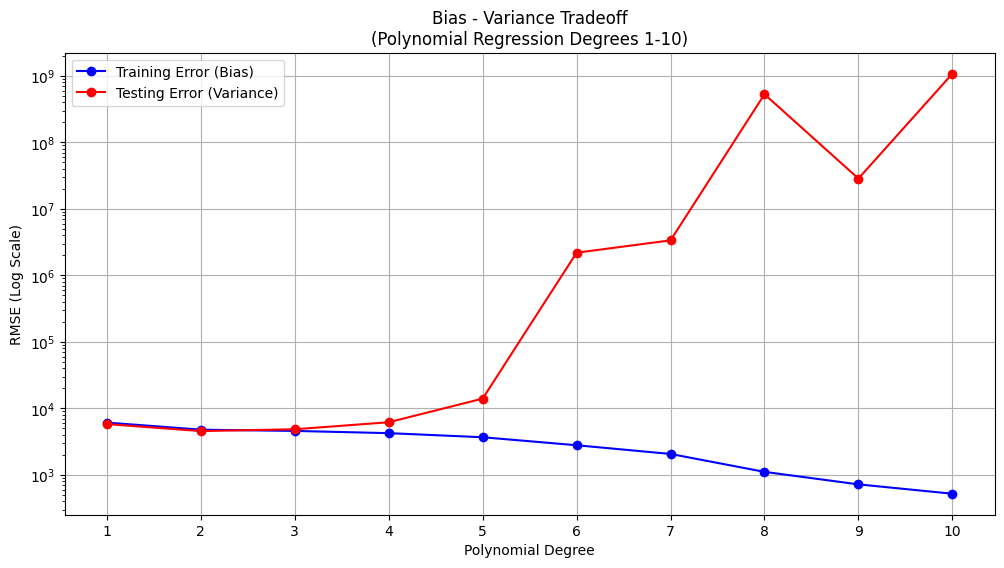

In [10]:
plt.figure(figsize=(12, 6))

# Plot Training Error (Bias proxy)
plt.plot(degrees, train_rmses, label='Training Error (Bias)', marker='o', color='blue')

# Plot Testing Error (Variance proxy)
plt.plot(degrees, test_rmses, label='Testing Error (Variance)', marker='o', color='red')

plt.title('Bias - Variance Tradeoff\n(Polynomial Regression Degrees 1-10)')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE (Root Mean Squared Error)')
plt.xticks(degrees)
plt.legend()
plt.grid(True)

plt.yscale('log')
plt.ylabel('RMSE (Log Scale)')

plt.show()